# Smart Energy Consumption Forecasting - Exploratory Data Analysis

## Nepal Electricity Authority (NEA) Daily Operations Report Analysis

This notebook performs comprehensive EDA on energy consumption data from Nepal's power grid.

In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading

Load the extracted energy data from PDF reports.

In [14]:
# Load the pre-extracted data from the PDF extraction notebook
# Run data_nea.ipynb first to generate these DataFrames

# Option 1: Load from saved CSV (if you saved them)
# energy_df = pd.read_csv('data/processed/energy_data.csv')
# demand_df = pd.read_csv('data/processed/demand_data.csv')

# Option 2: Re-extract from PDFs
import sys
sys.path.append('..')
from src.scraper.weather_scraper import WeatherScraper
from src.scraper.holiday_scraper import HolidayScraper

print("Loading data from PDF extraction...")

Loading data from PDF extraction...


In [15]:
# Run PDF extraction code
from pathlib import Path
import pdfplumber

pdf_dir = Path('../data') if Path('../data').exists() else Path('data')
pdf_files = sorted(pdf_dir.glob('NMOR*.pdf'))

daily_columns = [
    'Date(Nepali)', 'Date(English)', 'Energy_generation_NEA', 'Energy_generation_NEA Subsidiary',
    'Energy_generation_IPP', 'Energy_generation_Import', 'Energy_generation_Total Energy Available',
    'Energy Export', 'Net Energy Met within the country (INPS Demand)', 'Energy Interruption',
    'Energy not served/Generation Deficit', 'Energy Requirement']

demand_columns = [
    'Date (Nepali)', 'Date (English)', 'Peak Time', 'Generation', 'Import',
    'Recorded peak Availability', 'Export', 'Demand at Peak Time', 'Interruption',
    'Deficit', 'Peak Demand met', 'Net value of exchange with India']

daily_rows, demand_rows = [], []

for pdf_path in pdf_files:
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages[:10]:
            for table in page.extract_tables() or []:
                for row in table:
                    if not row or len(row) < 12:
                        continue
                    
                    date = (row[0] or '').strip()
                    if '/' not in date or len(date.replace('/', '').replace(' ', '')) != 8:
                        continue
                    
                    if date.count('/') == 1:
                        date = date[:2] + '/' + date[3:5] + '/' + date[5:]
                    
                    third = (row[2] or '').strip()
                    row[0] = date
                    
                    if ':' in third:
                        demand_rows.append(row[:12])
                    elif third.replace(',', '').replace('-', '').isdigit():
                        daily_rows.append(row[:12])

energy_df = pd.DataFrame(daily_rows, columns=daily_columns)
demand_df = pd.DataFrame(demand_rows, columns=demand_columns)

print(f"Energy data: {len(energy_df)} records")
print(f"Peak demand data: {len(demand_df)} records")

Energy data: 606 records
Peak demand data: 604 records


## 2. Data Cleaning & Preprocessing

In [16]:
# Clean energy data
def clean_energy_data(df, date_col='Date(English)'):
    """Clean and preprocess energy data."""
    df = df.copy()
    
    # Find the date column (might have different spacing)
    date_cols = [col for col in df.columns if 'Date(English)' in col or 'Date (English)' in col]
    if date_cols:
        actual_date_col = date_cols[0]
    else:
        actual_date_col = date_col
    
    # Convert numeric columns
    date_cols_to_exclude = [col for col in df.columns if 'Date' in col]
    numeric_cols = [col for col in df.columns if col not in date_cols_to_exclude]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')
    
    # Parse dates - rename to standard column name
    df['date'] = pd.to_datetime(df[actual_date_col], format='%d/%m/%Y', errors='coerce')
    
    # Remove duplicates and sort
    df = df.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)
    
    return df

energy_clean = clean_energy_data(energy_df)
demand_clean = clean_energy_data(demand_df)

print("Data cleaned successfully!")
print(f"\nDate range: {energy_clean['date'].min()} to {energy_clean['date'].max()}")
print(f"\nMissing values in energy data:")
print(energy_clean.isnull().sum())

Data cleaned successfully!

Date range: 2022-07-17 00:00:00 to 2024-03-13 00:00:00

Missing values in energy data:
Date(Nepali)                                       0
Date(English)                                      0
Energy_generation_NEA                              0
Energy_generation_NEA Subsidiary                   0
Energy_generation_IPP                              0
Energy_generation_Import                           0
Energy_generation_Total Energy Available           0
Energy Export                                      0
Net Energy Met within the country (INPS Demand)    0
Energy Interruption                                0
Energy not served/Generation Deficit               0
Energy Requirement                                 0
date                                               0
dtype: int64


In [17]:
# Basic statistics
print("="*60)
print("ENERGY DATA STATISTICS")
print("="*60)
energy_clean.describe()

ENERGY DATA STATISTICS


,Energy_generation_NEA,Energy_generation_NEA Subsidiary,Energy_generation_IPP,Energy_generation_Import,Energy_generation_Total Energy Available,Energy Export,Net Energy Met within the country (INPS Demand),Energy Interruption,Energy not served/Generation Deficit,Energy Requirement,date
count,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.000000,606.0,606.000000,606
mean,7935.437294,7180.052805,16463.564356,4607.348680,36186.412541,4609.910891,31576.491749,614.965347,0.0,32191.457096,2023-05-15 12:00:00
min,3864.000000,1467.000000,7915.000000,0.000000,22456.000000,0.000000,18936.000000,0.000000,0.0,18936.000000,2022-07-17 00:00:00
25%,6601.500000,3135.250000,11199.000000,40.500000,30155.000000,0.000000,28631.750000,0.000000,0.0,29383.750000,2022-12-15 06:00:00
50%,8268.000000,5661.500000,16017.000000,1321.500000,33111.000000,3074.000000,31264.500000,167.500000,0.0,32248.000000,2023-05-15 12:00:00
75%,9366.750000,12570.000000,20575.750000,10170.000000,42813.000000,8745.000000,34792.000000,1100.000000,0.0,35238.000000,2023-10-13 18:00:00
max,11491.000000,14178.000000,28579.000000,15641.000000,52213.000000,17555.000000,41564.000000,4285.000000,0.0,42190.000000,2024-03-13 00:00:00
std,1743.484692,4290.420231,5727.967282,5182.601198,7132.806446,4899.106112,4525.652946,811.664895,0.0,4613.491757,NaN


## 3. Temporal Analysis

In [18]:
# Add time features
energy_clean['month'] = energy_clean['date'].dt.month
energy_clean['day_of_week'] = energy_clean['date'].dt.dayofweek
energy_clean['day_name'] = energy_clean['date'].dt.day_name()
energy_clean['week_of_year'] = energy_clean['date'].dt.isocalendar().week
energy_clean['year'] = energy_clean['date'].dt.year
energy_clean['quarter'] = energy_clean['date'].dt.quarter

# Season mapping (Nepal-specific)
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring',
    5: 'Summer', 6: 'Summer', 7: 'Summer',
    8: 'Monsoon', 9: 'Monsoon',
    10: 'Autumn', 11: 'Autumn'
}
energy_clean['season'] = energy_clean['month'].map(season_map)

print("Time features added!")

Time features added!


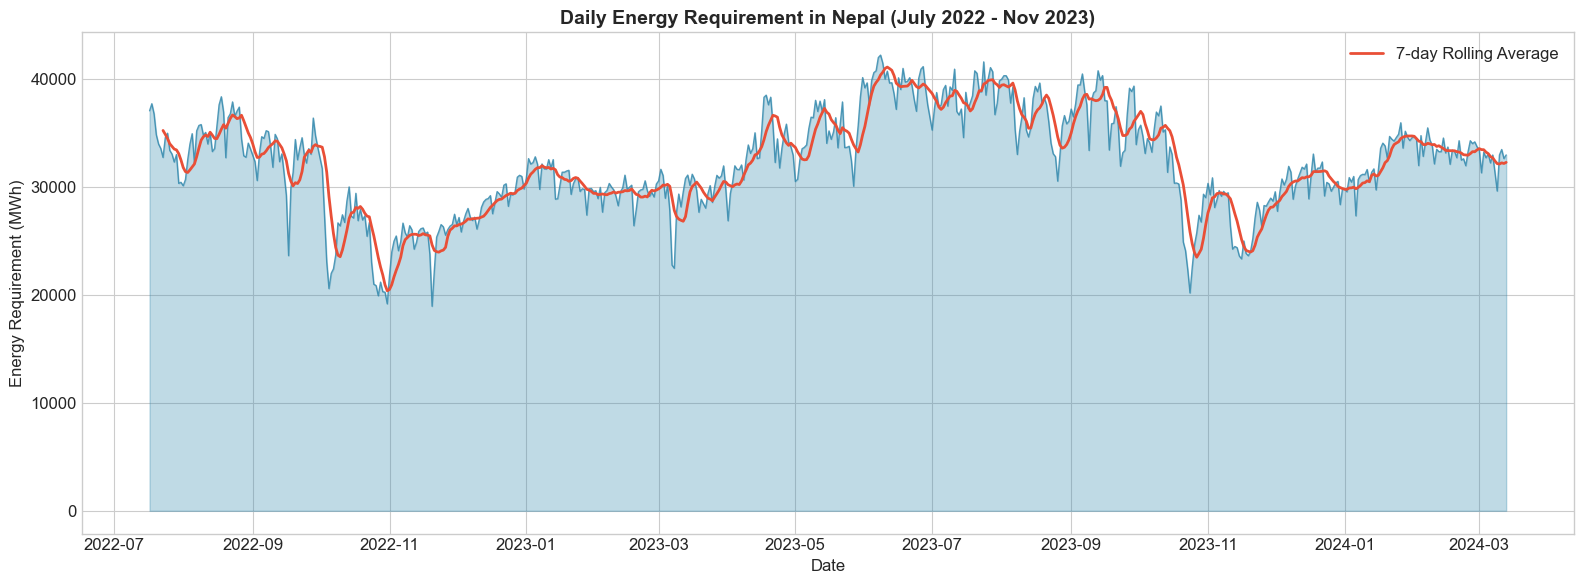

In [19]:
# Plot: Daily Energy Requirement Over Time
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(energy_clean['date'], energy_clean['Energy Requirement'], 
        color='#2E86AB', linewidth=1, alpha=0.8)
ax.fill_between(energy_clean['date'], energy_clean['Energy Requirement'], 
                alpha=0.3, color='#2E86AB')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Energy Requirement (MWh)', fontsize=12)
ax.set_title('Daily Energy Requirement in Nepal (July 2022 - Nov 2023)', fontsize=14, fontweight='bold')

# Add rolling average
rolling_avg = energy_clean['Energy Requirement'].rolling(window=7).mean()
ax.plot(energy_clean['date'], rolling_avg, color='#E94F37', 
        linewidth=2, label='7-day Rolling Average')

ax.legend()
plt.tight_layout()
plt.savefig('../reports/energy_requirement_trend.png', dpi=150)
plt.show()

In [ ]:
# Plot: Energy Generation Mix
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Generation sources over time
ax1 = axes[0, 0]
ax1.stackplot(energy_clean['date'], 
              energy_clean['Energy_generation_NEA'],
              energy_clean['Energy_generation_NEA Subsidiary'],
              energy_clean['Energy_generation_IPP'],
              energy_clean['Energy_generation_Import'],
              labels=['NEA', 'NEA Subsidiary', 'IPP', 'Import'],
              alpha=0.8)
ax1.set_title('Energy Generation Mix Over Time', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy (MWh)')
ax1.legend(loc='upper left')

# Average generation by source
ax2 = axes[0, 1]
gen_sources = ['Energy_generation_NEA', 'Energy_generation_NEA Subsidiary', 
               'Energy_generation_IPP', 'Energy_generation_Import']
gen_means = energy_clean[gen_sources].mean()
gen_means.index = ['NEA', 'NEA Subsidiary', 'IPP', 'Import']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
ax2.bar(gen_means.index, gen_means.values, color=colors)
ax2.set_title('Average Daily Energy by Source', fontweight='bold')
ax2.set_ylabel('Energy (MWh)')

# Export vs Import trend
ax3 = axes[1, 0]
ax3.plot(energy_clean['date'], energy_clean['Energy Export'], 
         label='Export', color='#28A745', alpha=0.7)
ax3.plot(energy_clean['date'], energy_clean['Energy_generation_Import'], 
         label='Import', color='#DC3545', alpha=0.7)
ax3.set_title('Energy Import vs Export Over Time', fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Energy (MWh)')
ax3.legend()

# Energy Interruption analysis (replacing Deficit which was all zeros)
ax4 = axes[1, 1]
ax4.fill_between(energy_clean['date'], energy_clean['Energy Interruption'], 
                 color='#E94F37', alpha=0.7)
ax4.set_title('Energy Interruption Over Time', fontweight='bold')
ax4.set_xlabel('Date')
ax4.set_ylabel('Energy Interruption (MWh)')

ax4.annotate('Note: Daily energy deficit was zero throughout\nthe period as Nepal met demand via generation + imports',
             xy=(0.5, 0.95), xycoords='axes fraction', ha='center', va='top',
             fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('../reports/generation_analysis.png', dpi=150)
plt.show()

# Print interruption statistics
print("\nEnergy Interruption Statistics:")
print(f"  Total Interruption: {energy_clean['Energy Interruption'].sum():,.0f} MWh")
print(f"  Mean Daily: {energy_clean['Energy Interruption'].mean():.2f} MWh")
print(f"  Max: {energy_clean['Energy Interruption'].max():,.0f} MWh")
print(f"  Days with Interruption: {(energy_clean['Energy Interruption'] > 0).sum()} / {len(energy_clean)}")

## 4. Seasonal & Weekly Patterns

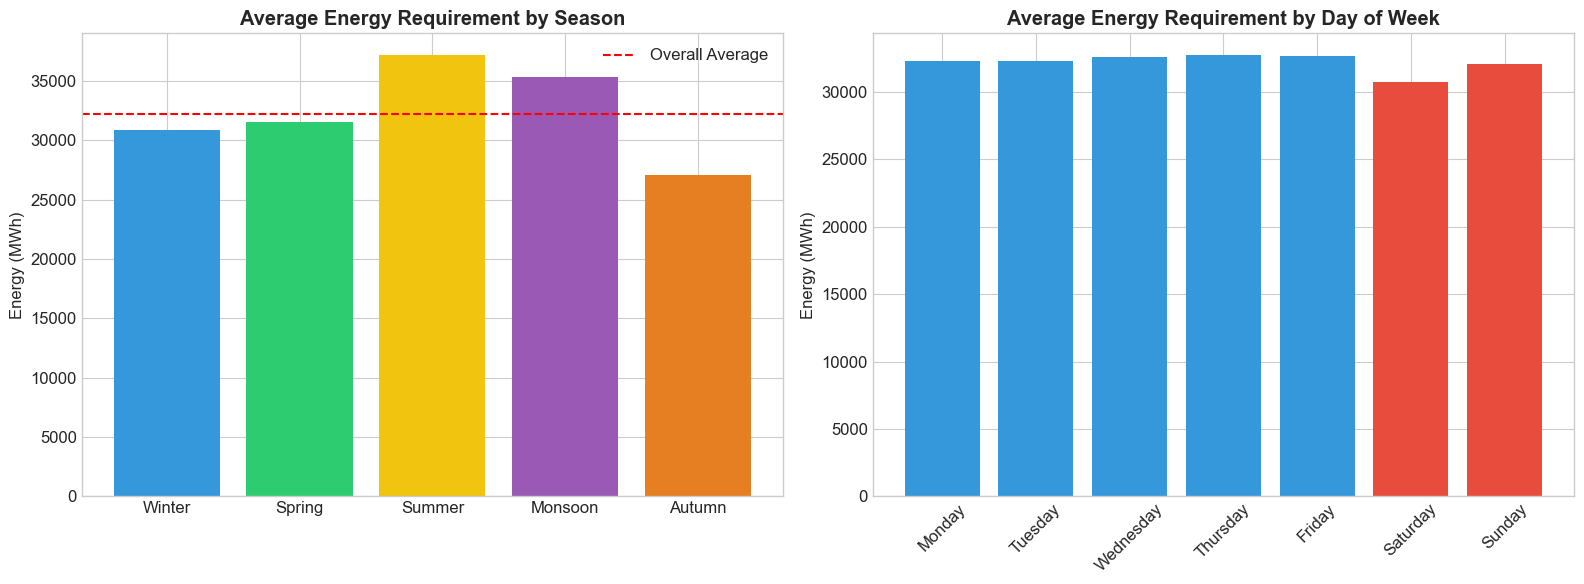

In [21]:
# Seasonal analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Energy by season
ax1 = axes[0]
seasonal_avg = energy_clean.groupby('season')['Energy Requirement'].mean().reindex(
    ['Winter', 'Spring', 'Summer', 'Monsoon', 'Autumn']
)
colors = ['#3498DB', '#2ECC71', '#F1C40F', '#9B59B6', '#E67E22']
bars = ax1.bar(seasonal_avg.index, seasonal_avg.values, color=colors)
ax1.set_title('Average Energy Requirement by Season', fontweight='bold')
ax1.set_ylabel('Energy (MWh)')
ax1.axhline(y=energy_clean['Energy Requirement'].mean(), color='red', 
            linestyle='--', label='Overall Average')
ax1.legend()

# Day of week analysis
ax2 = axes[1]
dow_avg = energy_clean.groupby('day_name')['Energy Requirement'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
colors = ['#3498DB'] * 5 + ['#E74C3C', '#E74C3C']  # Weekend in red
ax2.bar(dow_avg.index, dow_avg.values, color=colors)
ax2.set_title('Average Energy Requirement by Day of Week', fontweight='bold')
ax2.set_ylabel('Energy (MWh)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/seasonal_patterns.png', dpi=150)
plt.show()

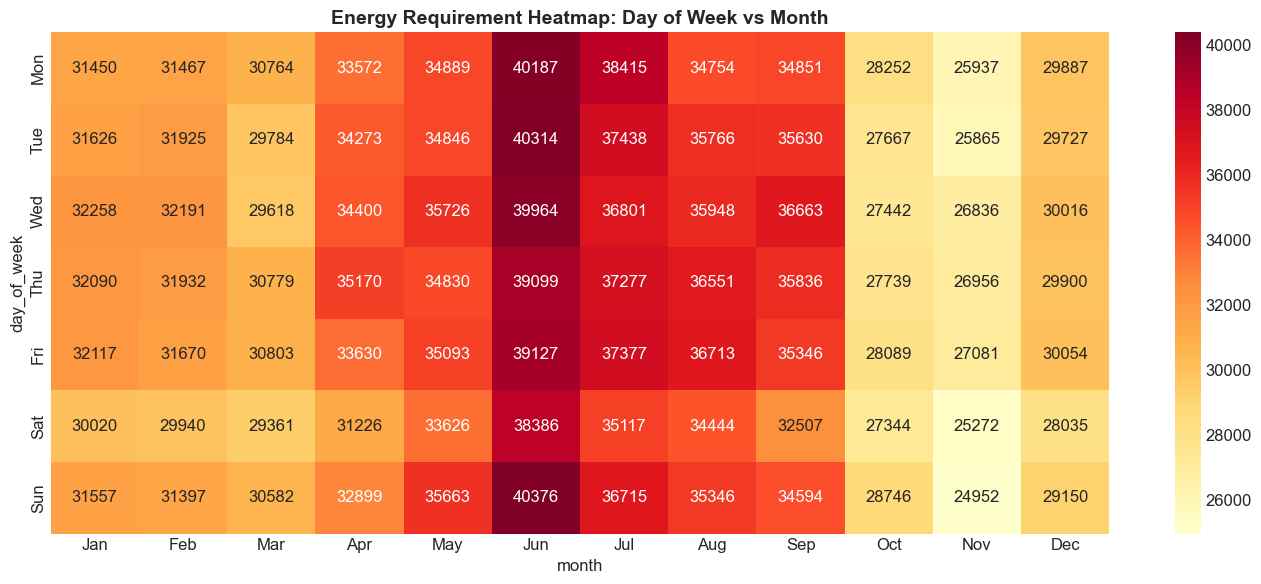

In [22]:
# Monthly heatmap
pivot_monthly = energy_clean.pivot_table(
    values='Energy Requirement', 
    index='day_of_week', 
    columns='month', 
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_monthly, 
            cmap='YlOrRd', 
            annot=True, 
            fmt='.0f',
            xticklabels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
            yticklabels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            ax=ax)
ax.set_title('Energy Requirement Heatmap: Day of Week vs Month', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/energy_heatmap.png', dpi=150)
plt.show()

## 5. Peak Demand Analysis

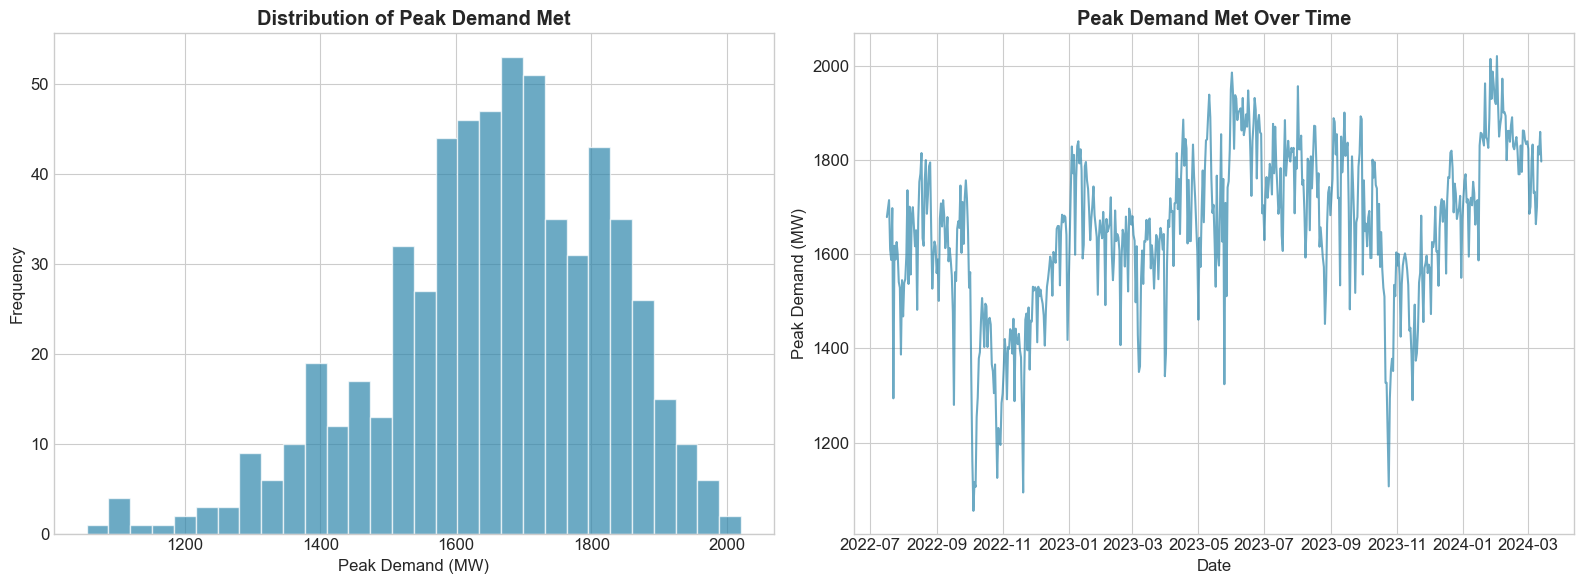

Peak Demand Statistics:
  Mean: 1654.53 MW
  Max:  2021.00 MW
  Min:  1055.00 MW


In [25]:
# Peak Demand Analysis
# Note: Peak Time column has no data extracted, so we'll focus on Peak Demand met

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Peak Demand Distribution (histogram)
ax1 = axes[0]
ax1.hist(demand_clean['Peak Demand met'].dropna(), bins=30, color='#2E86AB', edgecolor='white', alpha=0.7)
ax1.set_title('Distribution of Peak Demand Met', fontweight='bold')
ax1.set_xlabel('Peak Demand (MW)')
ax1.set_ylabel('Frequency')

# Peak Demand Over Time
ax2 = axes[1]
ax2.plot(demand_clean['date'], demand_clean['Peak Demand met'], color='#2E86AB', alpha=0.7)
ax2.set_title('Peak Demand Met Over Time', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Peak Demand (MW)')

plt.tight_layout()
plt.savefig('../reports/peak_demand_analysis.png', dpi=150)
plt.show()

# Print some statistics
print(f"Peak Demand Statistics:")
print(f"  Mean: {demand_clean['Peak Demand met'].mean():.2f} MW")
print(f"  Max:  {demand_clean['Peak Demand met'].max():.2f} MW")
print(f"  Min:  {demand_clean['Peak Demand met'].min():.2f} MW")

## 6. Correlation Analysis

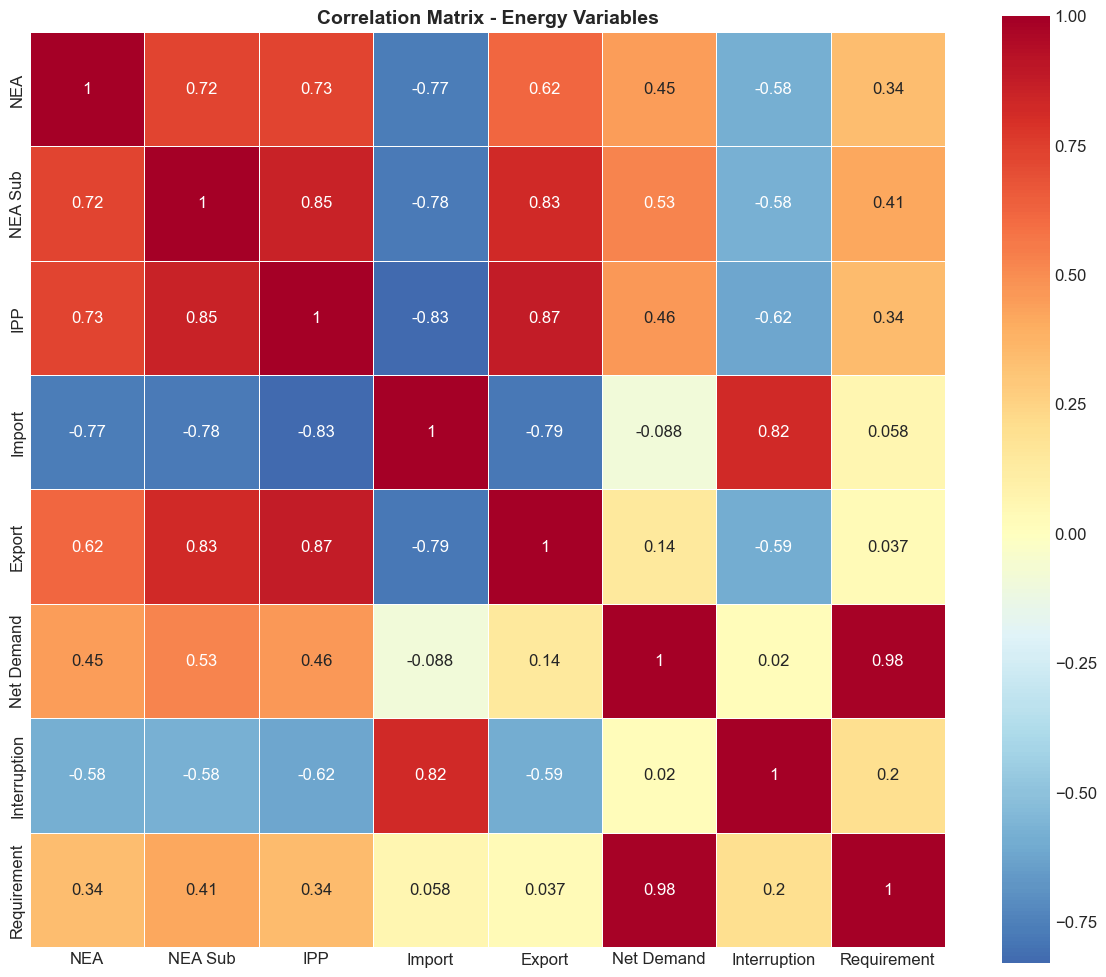

In [26]:
# Correlation matrix
numeric_cols = ['Energy_generation_NEA', 'Energy_generation_NEA Subsidiary',
                'Energy_generation_IPP', 'Energy_generation_Import',
                'Energy Export', 'Net Energy Met within the country (INPS Demand)',
                'Energy Interruption', 'Energy Requirement']

corr_matrix = energy_clean[numeric_cols].corr()

# Simplified column names for display
corr_matrix.columns = ['NEA', 'NEA Sub', 'IPP', 'Import', 'Export', 
                       'Net Demand', 'Interruption', 'Requirement']
corr_matrix.index = corr_matrix.columns

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix - Energy Variables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150)
plt.show()

## 7. Anomaly Detection (Statistical)

In [27]:
# Detect anomalies using Z-score and IQR methods
def detect_anomalies(series, method='zscore', threshold=3):
    """Detect anomalies in a time series."""
    if method == 'zscore':
        z_scores = np.abs((series - series.mean()) / series.std())
        return z_scores > threshold
    elif method == 'iqr':
        Q1, Q3 = series.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        return (series < lower) | (series > upper)

# Detect anomalies in energy requirement
energy_clean['anomaly_zscore'] = detect_anomalies(energy_clean['Energy Requirement'], method='zscore')
energy_clean['anomaly_iqr'] = detect_anomalies(energy_clean['Energy Requirement'], method='iqr')

print(f"Z-score anomalies: {energy_clean['anomaly_zscore'].sum()}")
print(f"IQR anomalies: {energy_clean['anomaly_iqr'].sum()}")

Z-score anomalies: 0
IQR anomalies: 7


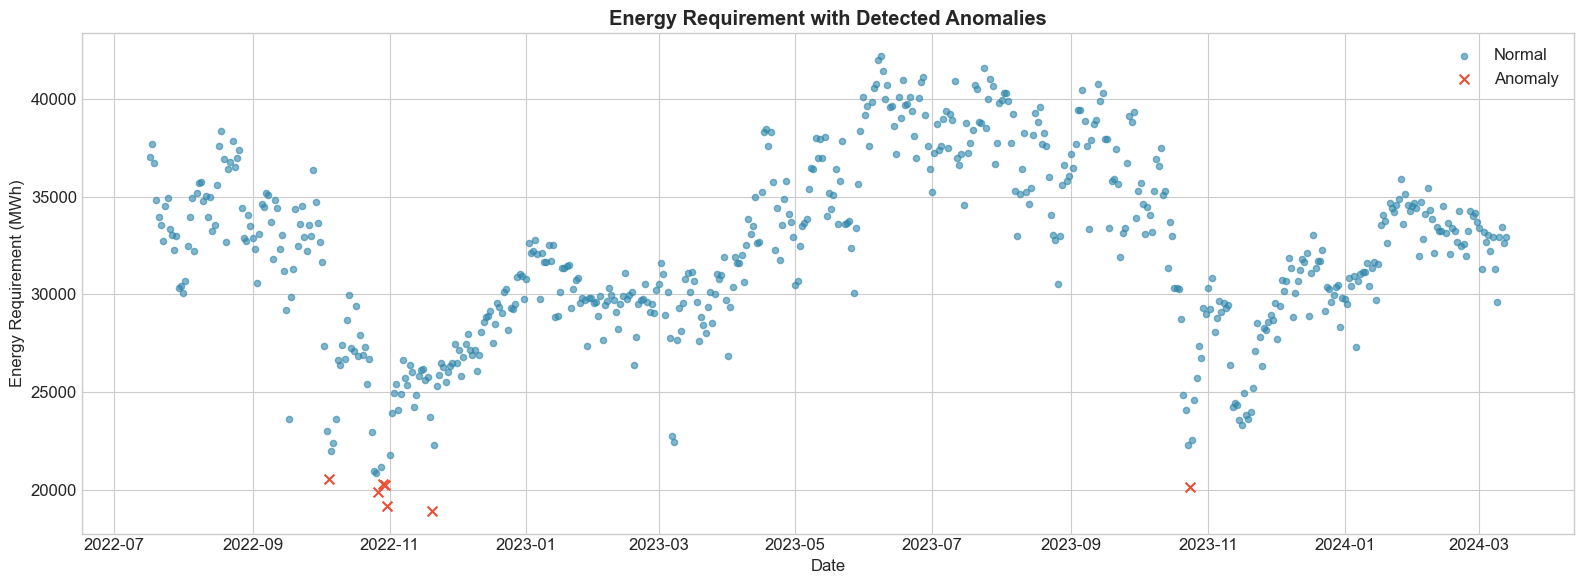

In [28]:
# Visualize anomalies
fig, ax = plt.subplots(figsize=(16, 6))

# Normal data
normal = energy_clean[~energy_clean['anomaly_iqr']]
anomalies = energy_clean[energy_clean['anomaly_iqr']]

ax.scatter(normal['date'], normal['Energy Requirement'], 
           c='#2E86AB', alpha=0.6, s=20, label='Normal')
ax.scatter(anomalies['date'], anomalies['Energy Requirement'], 
           c='#E94F37', s=50, label='Anomaly', marker='x')

ax.set_title('Energy Requirement with Detected Anomalies', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Requirement (MWh)')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/anomaly_detection.png', dpi=150)
plt.show()

## 8. Save Processed Data

In [ ]:
# Save cleaned and feature-engineered data
energy_clean.to_csv('../data/processed/energy_clean.csv', index=False)
demand_clean.to_csv('../data/processed/demand_clean.csv', index=False)

print("Processed data saved successfully!")
print("Files saved in: data/processed/")

Processed data saved successfully!
Files saved in: data/processed/


## 9. Key Insights Summary

### From this EDA, we observe:

1. **Seasonal Patterns**: Energy demand varies significantly by season
2. **Generation Mix**: IPPs contribute the largest share of generation
3. **Import/Export**: Nepal both imports and exports energy seasonally
4. **Peak Hours**: Most peak demands occur in evening hours (18:00-21:00)
5. **Anomalies**: Statistical methods can identify unusual consumption days

### Next Steps:
- Merge with weather data for correlation analysis
- Add holiday features
- Build forecasting models